# ICT-39 — Composition de regards

**Navigation** : [← ICT-37](./ICT-37-FLens-BeliefState.ipynb)

**Grain** : opération 12, « Composer des regards », issue #12204.  
**Prérequis** : fonctions, composition, arithmétique modulo 3.  
**Durée estimée** : 1 h 15.

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. distinguer la lecture avant (`get`/`play`) de la demande arrière (`put`/`coplay`) ;
2. composer réellement ces deux jambes ;
3. construire un témoin falsifiable où deux regards s'accordent en avant mais divergent en arrière ;
4. vérifier exhaustivement l'associativité sur un domaine fini.

> **Question scientifique.** Deux regards qui s'accordent sur tout ce qu'ils lisent s'accordent-ils nécessairement sur ce qu'ils demandent au monde ?

Cette trajectoire est indépendante de GameTheory-18 : ce dernier renvoie une paire de fonctions dans son arrière composé, tandis qu'ici la demande est calculée et propagée. Le substrat est épistémique et fini, non un jeu stratégique.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ict import regards as rg

print(f"Imports chargés : numpy {np.__version__}, famille de {len(rg.reference_family())} regards")

Imports chargés : numpy 2.4.4, famille de 10 regards


## 1 — Une lecture est une lentille finie

Un regard de la strate $X$ vers la strate $Y$ possède :

- une lecture avant $get : X \to Y$ ;
- une mise à jour arrière $put : X \times Y \to X$.

Il est cohérent lorsque deux lois tiennent :

$$put(x, get(x)) = x \qquad \text{(get-put)}$$

$$get(put(x, y)) = y \qquad \text{(put-get)}$$

Le banc utilise $W=\mathbb{Z}_3\times\mathbb{Z}_3$, $Z_3$ et $Z_2$. Ces domaines sont déclarés : l'énumération qui suit est exhaustive, pas un échantillon.

In [2]:
family = rg.reference_family()
print("Strates finies :")
for name, values in rg.STRATA.items():
    print(f"  {name}: {len(values)} éléments — {values}")
print("Regards :", ", ".join(g.name for g in family))

Strates finies :
  W: 9 éléments — ((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2))
  Z3: 3 éléments — (0, 1, 2)
  Z2: 2 éléments — (0, 1)
Regards : idW, idZ3, idZ2, SWAP, LUM, LUM-D, CHG, CHG-D, SHIFT, MEMO


### Vérification des composants

Chaque regard de référence doit satisfaire les deux lois avant que sa composition ait un sens. `LUM` conserve la charge cachée ; `LUM-D` l'entraîne avec la correction demandée. Ces deux transports sont différents mais peuvent être également licites.

In [3]:
law_rows = [rg.law_report(g) for g in family]
print(f"{'regard':<8} {'type':<8} {'get-put':>9} {'put-get':>9} {'lentille':>10}")
for row in law_rows:
    gp = len(row['get_put_violations'])
    pg = len(row['put_get_violations'])
    print(f"{row['name']:<8} {row['src']+'→'+row['tgt']:<8} {gp:>3}/{row['n_get_put']:<5} {pg:>3}/{row['n_put_get']:<5} {str(row['is_lens']):>10}")

regard   type       get-put   put-get   lentille
idW      W→W        0/9       0/81          True
idZ3     Z3→Z3      0/3       0/9           True
idZ2     Z2→Z2      0/2       0/4           True
SWAP     W→W        0/9       0/81          True
LUM      W→Z3       0/9       0/27          True
LUM-D    W→Z3       0/9       0/27          True
CHG      W→Z3       0/9       0/27          True
CHG-D    W→Z3       0/9       0/27          True
SHIFT    Z3→Z3      0/3       0/9           True
MEMO     Z3→Z2      0/3       0/6           True


### Lecture du résultat : deux arrières licites

Les dix lignes affichent zéro violation. L'accord sur les lois ne rend donc pas le transport arrière unique : `LUM` et `LUM-D` restent tous deux des regards cohérents. Cette multiplicité rend possible un test d'incompatibilité non trivial.

## 2 — Composer les deux jambes

Pour $g_1:X\to Y$ puis $g_2:Y\to Z$ :

$$(g_2\circ g_1).get(x)=g_2.get(g_1.get(x))$$

$$(g_2\circ g_1).put(x,z)=g_1.put\left(x, g_2.put(g_1.get(x),z)\right).$$

La réinjection de $g_1.get(x)$ dans l'arrière de $g_2$, puis l'appel de l'arrière de $g_1$, sont essentiels. L'arrière composé ne renvoie pas des fonctions : il calcule une demande sur $X$.

In [4]:
composites = [rg.compose(g2, g1) for g1 in family for g2 in family if g1.tgt == g2.src]
invalid = [g.name for g in composites if not rg.law_report(g)['is_lens']]
unit_failures = 0
for g in family:
    left = rg.compose(rg.identity(g.tgt), g)
    right = rg.compose(g, rg.identity(g.src))
    for candidate in (left, right):
        unit_failures += len(rg.agreement(candidate, g, on='get')['disagreements'])
        unit_failures += len(rg.agreement(candidate, g, on='put')['disagreements'])
print(f"Couples composables : {len(composites)}")
print(f"Composites non-lentilles : {len(invalid)}")
print(f"Écarts aux unités : {unit_failures}")

Couples composables : 32
Composites non-lentilles : 0
Écarts aux unités : 0


### Lecture du résultat : clôture et unités

Les 32 couples composables restent dans la classe des lentilles, et les identités ne changent aucune jambe. La composition forme donc un langage fermé sur ce banc fini.

## 3 — Témoin : accord avant, désaccord arrière

`LUM` et `LUM-D` lisent tous deux la première coordonnée. Le premier conserve la charge cachée ; le second la décale de la correction $y-s$. Nous testons toutes les paires état-demande, sans sélectionner un exemple favorable après coup.

In [5]:
by_name = {g.name: g for g in family}
forward = rg.agreement(by_name['LUM'], by_name['LUM-D'], on='get')
backward = rg.agreement(by_name['LUM'], by_name['LUM-D'], on='put')
print(f"Accord avant : {forward['same']}/{forward['total']} = {forward['rate']:.3f}")
print(f"Accord arrière : {backward['same']}/{backward['total']} = {backward['rate']:.3f}")
print(f"Désaccords arrière : {len(backward['disagreements'])}/{backward['total']}")
print("Premier témoin :", backward['disagreements'][0])

Accord avant : 9/9 = 1.000
Accord arrière : 9/27 = 0.333
Désaccords arrière : 18/27
Premier témoin : ((0, 0), 1, (1, 0), (1, 1))


### Lecture du résultat : l'avant ne détermine pas l'arrière

L'accord avant est total, tandis que l'accord arrière ne survient que lorsque la demande égale la valeur déjà lue. Les 18 autres couples forment un témoin falsifiable : une compatibilité écrite seulement sur les verdicts avant — comme le recollement d'ICT-34 — ne peut pas voir cette obstruction.

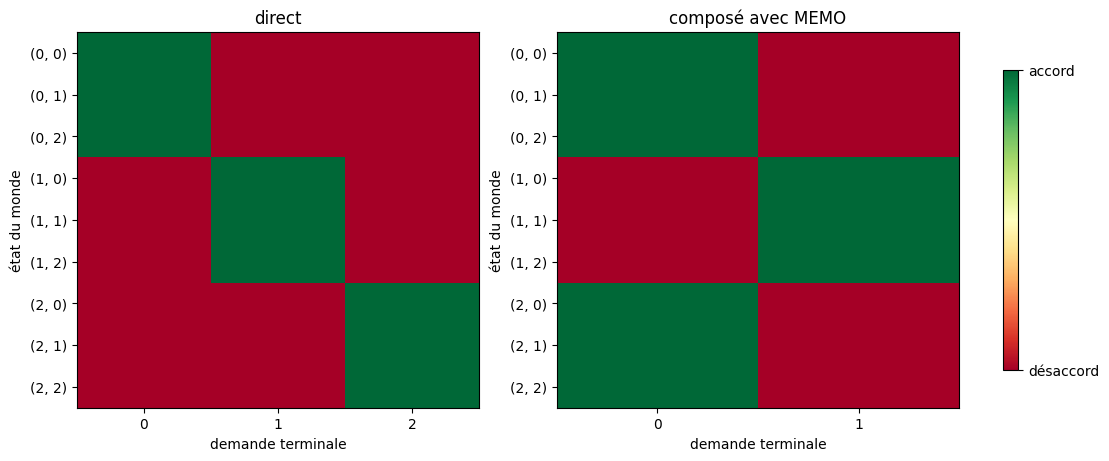

La figure localise les accords et désaccords arrière pour chaque état et demande.


In [6]:
memo_lum = rg.compose(by_name['MEMO'], by_name['LUM'])
memo_lum_d = rg.compose(by_name['MEMO'], by_name['LUM-D'])
pairs = [(by_name['LUM'], by_name['LUM-D'], 'direct'), (memo_lum, memo_lum_d, 'composé avec MEMO')]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (left, right, title) in zip(axes, pairs):
    data = np.array([[left.put(w, y) == right.put(w, y) for y in rg.elements(left.tgt)] for w in rg.elements('W')], dtype=int)
    image = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('demande terminale')
    ax.set_ylabel('état du monde')
    ax.set_xticks(range(len(rg.elements(left.tgt))))
    ax.set_xticklabels(rg.elements(left.tgt))
    ax.set_yticks(range(len(rg.elements('W'))))
    ax.set_yticklabels(rg.elements('W'))
colorbar = fig.colorbar(image, ax=axes, ticks=[0, 1], shrink=0.8)
colorbar.ax.set_yticklabels(['désaccord', 'accord'])
plt.show()
print("La figure localise les accords et désaccords arrière pour chaque état et demande.")

### Lecture de la figure : diagonale puis repliement

Dans le panneau direct, les cases d'accord forment une diagonale répétée : chaque regard reconstruit le même monde uniquement lorsque la demande terminale égale le signal initial. Après composition avec `MEMO`, les trois colonnes de $Z_3$ sont ramenées aux deux demandes de $Z_2$ : les signaux 0 et 2 partagent alors le même profil pair, tandis que le signal 1 conserve le profil impair. La composition transporte donc l'incompatibilité en en modifiant la géométrie observable.

### Exercice 1 — Une troisième lecture entraînante

Construisez `LUM-D2`, qui décale la charge cachée de deux fois la correction, puis mesurez ses accords avec `LUM`.

- `# Indice` : reprenez la forme de `LUM-D` dans `reference_family`.
- `# Étape 1` : définissez le regard.
- `# Étape 2` : appelez `rg.agreement` sur les deux jambes.
- `# Étape 3` : expliquez si l'avant détermine davantage l'arrière.

In [7]:
lum_d2 = None  # TODO étudiant : construire le regard LUM-D2
exercise_1_report = None  # TODO étudiant : mesurer les accords
print("Exercice 1 à compléter : LUM-D2 et son rapport d'accord.")

Exercice 1 à compléter : LUM-D2 et son rapport d'accord.


## 4 — Le témoin survit à la composition

Nous composons les deux regards avec `MEMO`, qui réduit $Z_3$ à un verdict dans $Z_2$. Nous comparons ensuite ce que voit le verdict et ce que voit un troisième regard, `CHG`, sur les mondes reconstruits.

In [8]:
composed = rg.agreement(memo_lum, memo_lum_d, on='put')
seen_by_signal = rg.witness_report(memo_lum, memo_lum_d, by_name['LUM'], 0)
seen_by_charge = rg.witness_report(memo_lum, memo_lum_d, by_name['CHG'], 0)
print(f"Composites — accord avant : {rg.agreement(memo_lum, memo_lum_d, on='get')['rate']:.3f}")
print(f"Composites — désaccords arrière : {len(composed['disagreements'])}/{composed['total']}")
print(f"Détectés par la lecture du signal : {seen_by_signal['n_detectable']}/9")
print(f"Détectés par CHG : {seen_by_charge['n_detectable']}/9 — {seen_by_charge['detected']}")

Composites — accord avant : 1.000
Composites — désaccords arrière : 9/18
Détectés par la lecture du signal : 0/9
Détectés par CHG : 3/9 — ((1, 0), (1, 1), (1, 2))


### Lecture du résultat : invisible dans le signal, visible dans la charge

La lecture du signal — et, a fortiori, le verdict binaire composé — masque le désaccord, mais `CHG` le détecte exactement sur les trois mondes de signal 1, là où `MEMO` effectue une correction. Composer n'efface donc pas l'ambiguïté : il la transporte vers une strate où certaines lectures la voient et d'autres non.

## 5 — Associativité extensionnelle

Le mot « composer » exige que le parenthésage ne change ni la lecture ni la demande :

$$g_3\circ(g_2\circ g_1)=(g_3\circ g_2)\circ g_1.$$

Nous comparons les deux fonctions en chaque état source et pour chaque demande terminale de tous les triples composables.

In [9]:
assoc = rg.associativity_report(family)
print(f"Triples composables : {assoc['n_composable_triples']}")
print(f"Points vérifiés : {assoc['n_points']}")
print(f"Violations d'associativité : {assoc['n_violations']}")

Triples composables : 92
Points vérifiés : 2422
Violations d'associativité : 0


### Lecture du résultat : exhaustive sur le domaine déclaré

Les 2 422 points couvrent tous les triples composables de la famille. Zéro violation atteste l'égalité extensionnelle sur ces strates finies ; cela ne prétend pas remplacer un théorème pour tous les types. Une formalisation Lean constituerait la suite naturelle vers l'opération 8, « Certifier ».

### Exercice 2 — Étendre la famille

Ajoutez un regard bien élevé de votre choix, puis rejouez le rapport d'associativité.

- `# Indice` : commencez par une bijection de $Z_3$.
- `# Étape 1` : vérifiez ses lois isolées.
- `# Étape 2` : ajoutez-le à une copie de `family`.
- `# Étape 3` : comparez le nombre de triples et de points.

In [10]:
new_regard = None  # TODO étudiant : définir un regard bien élevé
exercise_2_report = None  # TODO étudiant : vérifier la famille étendue
print("Exercice 2 à compléter : extension et nouvelle vérification exhaustive.")

Exercice 2 à compléter : extension et nouvelle vérification exhaustive.


## 6 — Contrôle négatif : oublier la réinjection

Un test utile doit pouvoir rougir. Le contrôle `compose_without_reinjection` oublie le `put` intérieur. Sur `SWAP ∘ SWAP`, nous comparons ses violations à la composition correcte.

In [11]:
correct = rg.law_report(rg.compose(by_name['SWAP'], by_name['SWAP']))
wrong = rg.law_report(rg.compose_without_reinjection(by_name['SWAP'], by_name['SWAP']))
print(f"Composition correcte : lentille={correct['is_lens']}, get-put={len(correct['get_put_violations'])}/9, put-get={len(correct['put_get_violations'])}/81")
print(f"Sans réinjection : lentille={wrong['is_lens']}, get-put={len(wrong['get_put_violations'])}/9, put-get={len(wrong['put_get_violations'])}/81")

Composition correcte : lentille=True, get-put=0/9, put-get=0/81
Sans réinjection : lentille=False, get-put=6/9, put-get=54/81


### Lecture du résultat : les lois ont un pouvoir propre

La règle fautive échoue sur 6 états et 54 couples état-demande. Ce contrôle montre que les lois détectent une omission concrète. Associativité et lois sont complémentaires : une opération fautive peut parfois rester associative tout en cessant de composer des lentilles.

### Exercice 3 — Diagnostiquer une composition fautive

Construisez une seconde règle fautive, localisez ses premières violations et proposez la réinjection manquante.

- `# Indice` : modifiez uniquement la jambe arrière.
- `# Étape 1` : produisez un `Regard` contrôle.
- `# Étape 2` : utilisez `law_report`.
- `# Étape 3` : expliquez quelle loi révèle le défaut.

In [12]:
wrong_rule = None  # TODO étudiant : construire une seconde règle fautive
exercise_3_report = None  # TODO étudiant : localiser les violations
print("Exercice 3 à compléter : contrôle négatif et diagnostic des lois.")

Exercice 3 à compléter : contrôle négatif et diagnostic des lois.


## 7 — Conclusion

| Résultat | Mesure attendue du banc | Portée |
|---|---:|---|
| Composants bien élevés | 10 regards, zéro violation | exhaustif sur les strates déclarées |
| Clôture | 32 couples, zéro composite invalide | famille de référence |
| Incompatibilité directe | accord avant total, 18/27 désaccords arrière | témoin construit et falsifiable |
| Survie à `MEMO` | 9/18 désaccords arrière | transport sous composition |
| Associativité | 92 triples, 2 422 points, zéro violation | égalité extensionnelle finie |
| Contrôle négatif | 6/9 et 54/81 violations | pouvoir discriminant des lois |

**Verdict.** Sur ce substrat synthétique, l'avant ne détermine pas l'arrière. La compatibilité pertinente pour composer des regards doit donc porter aussi sur le transport des demandes. Cette attestation est empirique et exhaustive sur le domaine déclaré ; elle ne généralise ni à tous les types ni à un substrat biologique réel.

### Références et continuité

- Foster et al., *Combinators for Bi-Directional Tree Transformations: A Linguistic Approach to the View Update Problem* — lois des lentilles.
- Hedges, *Coherence for lenses and open games* — composition avant/arrière ; frontière avec GameTheory-18.
- ICT-34 — banc de recollement dont la compatibilité est formulée sur les verdicts avant.
- Ledger #12204 — opération 12 et exigence d'une seconde instanciation directe indépendante.

In [13]:
verdict = rg.op12_verdict()
print("VERDICT OPÉRATION 12")
print(f"Composants licites : {sum(row['is_lens'] for row in verdict['laws'])}/{len(verdict['laws'])}")
print(f"Témoin direct : avant={verdict['witness_direct']['forward_rate']:.3f}, désaccords arrière={verdict['witness_direct']['n_backward_disagreements']}/{verdict['witness_direct']['n_backward_slots']}")
print(f"Témoin composé : {verdict['witness_composed']['memo']['n_backward_disagreements']}/{verdict['witness_composed']['memo']['n_backward_slots']} désaccords")
print(f"Associativité : {verdict['associativity']['n_violations']} violation sur {verdict['associativity']['n_points']} points")
print(f"Contrôle fautif : {len(verdict['control_wrong']['get_put_violations'])} get-put et {len(verdict['control_wrong']['put_get_violations'])} put-get")

VERDICT OPÉRATION 12
Composants licites : 10/10
Témoin direct : avant=1.000, désaccords arrière=18/27
Témoin composé : 9/18 désaccords
Associativité : 0 violation sur 2422 points
Contrôle fautif : 6 get-put et 54 put-get
